<a href="https://colab.research.google.com/github/mvenyidonny/MyFiles/blob/main/models_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1 DATA ACQUISITION
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier # Or lightgbm.LGBMClassifier
from sklearn.neural_network import MLPClassifier # Simple Neural Network for structured data
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import re # For basic text cleaning
import time
from google.colab import drive


In [3]:

# Unmount the drive first if it was previously mounted.
try:
    drive.flush_and_unmount()
    print('All changes made in this colab session should now be visible in your Google Drive.')
except ValueError:
    pass  # Ignore errors if drive was not mounted


Drive not mounted, so nothing to flush and unmount.
All changes made in this colab session should now be visible in your Google Drive.


In [4]:

# Mount Google Drive.

drive.mount('/content/drive')

try:
    # Load a sample phishing dataset
    data = pd.read_csv("/content/drive/My Drive/internship_4_ccmc/Dataset.csv")
except FileNotFoundError:
    print("Error: Dataset.csv not found. Please provide the correct path.")
    exit()

print(f"Shape of the initial dataset: {data.shape}")
#print(data.head())

Mounted at /content/drive
Shape of the initial dataset: (247950, 42)


In [5]:
# --- 1. Generate Dummy Text Data (Replace with your actual data loading) ---
# In a real scenario, load your text data and labels.
# Example: df = pd.read_csv('your_text_data.csv')
#          texts = df['text_column'].tolist()
#          labels = df['label_column'].tolist()
import numpy as np
np.random.seed(42) # for reproducibility
num_samples = 2000
dummy_texts = [
    "This product is amazing and works perfectly. Highly recommend!",
    "I had a terrible experience with this service. Very disappointed.",
    "The quality is good for the price. Not bad at all.",
    "Customer support was unhelpful and rude. Avoid this company.",
    "Fast delivery and exactly what I ordered. Happy customer.",
    "The software crashed frequently, making it unusable.",
    "A truly innovative solution to a long-standing problem.",
    "Waste of money. Doesn't do what it promises.",
    "Decent performance, nothing revolutionary.",
    "My best purchase this year. So convenient.",
    "The worst ever, never again.",
    "Fantastic value, great features.",
    "So slow and buggy, frustrating to use.",
    "Exceeded expectations, thrilled with results.",
    "Mediocre at best, would not buy again.",
    "Brilliant design and user-friendly interface.",
    "Buggy software, constant errors.",
    "Very satisfied, five stars!",
    "Poor customer service, long wait times.",
    "A solid choice for everyday use.",
] * (num_samples // 20) # Repeat to get enough samples

dummy_labels = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
    0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
] * (num_samples // 20)

# Randomly shuffle (important if repeating patterns)
combined = list(zip(dummy_texts, dummy_labels))
np.random.shuffle(combined)
texts, labels = zip(*combined)

# --- 2. Basic Text Preprocessing ---
def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation (keep alphanumeric and spaces)
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

processed_texts = [preprocess_text(text) for text in texts]

# --- 3. Feature Extraction (TF-IDF) ---
# For more complex text analysis with Neural Networks, you'd typically use word embeddings
# (e.g., Word2Vec, GloVe, or contextual embeddings from BERT/Transformer models).
# TF-IDF is suitable for Logistic Regression, SVM, Random Forests, Gradient Boosting.

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(processed_texts)
y = np.array(labels)

# --- 4. Data Splitting ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (1600, 76)
Test set shape: (400, 76)


In [6]:
# --- 5. Model Training and Evaluation ---

models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', C=1.0), # C is regularization inverse
    "SVM": SVC(probability=True, random_state=42, kernel='linear', C=1.0), # kernel='linear' for speed with high dim data
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Gradient Boosting (XGBoost)": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": lightgbm.LGBMClassifier(random_state=42), # Uncomment if you have LightGBM installed
    "Neural Network (MLP)": MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=300, activation='relu', solver='adam')
}

performance_metrics = {}
roc_data = {}

print("\n--- Training and Evaluating Models ---")
for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    print(f"Training time: {training_time:.2f} seconds")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Probability for ROC curve

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    performance_metrics[name] = {
        "Accuracy": accuracy,
        "Classification Report": report,
        "Confusion Matrix": cm
    }

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc}

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Classification Report:\n{classification_report(y_test, y_pred)}")
    print(f"  Confusion Matrix:\n{cm}")



--- Training and Evaluating Models ---

Training Logistic Regression...
Training time: 0.01 seconds
  Accuracy: 1.0000
  Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00       220

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

  Confusion Matrix:
[[180   0]
 [  0 220]]

Training SVM...
Training time: 0.02 seconds
  Accuracy: 1.0000
  Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00       220

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

  Confusion Matrix:
[[180   0]
 [  0 220]]

Training Random Forest...

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:35:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training time: 0.50 seconds
  Accuracy: 1.0000
  Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00       220

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

  Confusion Matrix:
[[180   0]
 [  0 220]]


In [7]:
# --- 6. Comparative Analysis ---
print("\n--- Comparative Performance Summary ---")
results_df = pd.DataFrame(columns=["Model", "Accuracy", "Precision (Class 0)", "Recall (Class 0)", "F1-Score (Class 0)",
                                   "Precision (Class 1)", "Recall (Class 1)", "F1-Score (Class 1)", "AUC"])

for name, metrics in performance_metrics.items():
    accuracy = metrics["Accuracy"]
    report = metrics["Classification Report"]
    auc_score = roc_data[name]["auc"]

    results_df = pd.concat([results_df, pd.DataFrame([{
        "Model": name,
        "Accuracy": accuracy,
        "Precision (Class 0)": report['0']['precision'],
        "Recall (Class 0)": report['0']['recall'],
        "F1-Score (Class 0)": report['0']['f1-score'],
        "Precision (Class 1)": report['1']['precision'],
        "Recall (Class 1)": report['1']['recall'],
        "F1-Score (Class 1)": report['1']['f1-score'],
        "AUC": auc_score
    }])], ignore_index=True)

results_df = results_df.set_index("Model")
print(results_df.round(4))



--- Comparative Performance Summary ---
                             Accuracy  Precision (Class 0)  Recall (Class 0)  \
Model                                                                          
Logistic Regression               1.0                  1.0               1.0   
SVM                               1.0                  1.0               1.0   
Random Forest                     1.0                  1.0               1.0   
Gradient Boosting (XGBoost)       1.0                  1.0               1.0   
Neural Network (MLP)              1.0                  1.0               1.0   

                             F1-Score (Class 0)  Precision (Class 1)  \
Model                                                                  
Logistic Regression                         1.0                  1.0   
SVM                                         1.0                  1.0   
Random Forest                               1.0                  1.0   
Gradient Boosting (XGBoost)           

<ipython-input-7-1e0b5a2a1a2e>:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([{


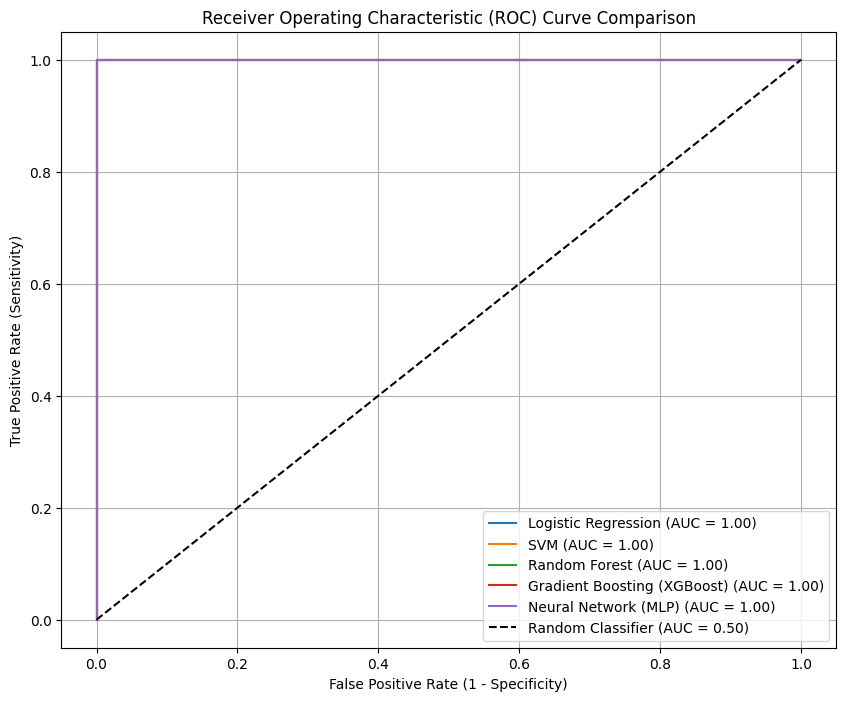


--- End of Model Comparison ---


In [8]:
# --- 7. Visualization of ROC Curves ---
plt.figure(figsize=(10, 8))
for name, data in roc_data.items():
    plt.plot(data["fpr"], data["tpr"], label=f'{name} (AUC = {data["auc"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("\n--- End of Model Comparison ---")